# Проверка датасета

**Задача:** подсчёт автомобилей на дорожном видео (детекция + трекинг).

**Датасет:** [AI Traffic System](https://universe.roboflow.com/object-detection-sn8ac/ai-traffic-system/dataset/1) (Roboflow), формат YOLO.

Этот notebook проверяет **пригодность датасета** перед обучением:

1. Соответствие задаче
2. Тип разметки
3. Объём данных
4. Качество разметки
5. Разбиение train / val / test
6. Баланс классов
7. Лицензия
8. Утечка данных между split

## Установка зависимостей

In [8]:
%pip install -q opencv-python matplotlib pandas pyyaml

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\777\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Пути и классы

In [9]:
from pathlib import Path
import yaml

PROJECT = Path(".").resolve()
DATA = (PROJECT / ".." / "archive (2)").resolve()
RESULTS = PROJECT / "results"
RESULTS.mkdir(exist_ok=True)

CLASS_NAMES = ["bicycle", "bus", "car", "motorbike", "rickshaw", "truck", "van"]
SPLITS = ["train", "valid", "test"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Проект:", PROJECT)
print("Датасет:", DATA)
assert DATA.exists(), f"Папка датасета не найдена: {DATA}"

data_yaml_path = DATA / "data.yaml"
if data_yaml_path.exists():
    print("\ndata.yaml из Roboflow:")
    print(data_yaml_path.read_text(encoding="utf-8"))

Проект: C:\Users\777\Desktop\8 сем\Практика\vehicle-counting
Датасет: C:\Users\777\Desktop\8 сем\Практика\archive (2)

data.yaml из Roboflow:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 7
names: ['bicycle', 'bus', 'car', 'motorbike', 'rickshaw', 'truck', 'van']

roboflow:
  workspace: object-detection-sn8ac
  project: ai-traffic-system
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/object-detection-sn8ac/ai-traffic-system/dataset/1


## Автоматический аудит split-ов

Для каждого split считаем:
- число изображений и label-файлов;
- несоответствия (картинка без разметки и наоборот);
- пустые label-файлы;
- некорректные bbox (координаты вне [0, 1], неверный class id);
- распределение объектов по классам.

In [10]:
from collections import Counter


def audit_split(name: str) -> dict:
    img_dir = DATA / name / "images"
    lbl_dir = DATA / name / "labels"

    images = {p.stem for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}
    labels = {p.stem for p in lbl_dir.glob("*.txt")}

    empty_labels = sum(1 for p in lbl_dir.glob("*.txt") if p.stat().st_size == 0)
    classes = Counter()
    bad_boxes = 0
    total_objects = 0
    widths, heights = [], []

    for p in lbl_dir.glob("*.txt"):
        for line in p.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            parts = line.split()
            if len(parts) != 5:
                bad_boxes += 1
                continue
            cls_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:])
            if not (0 <= cls_id < len(CLASS_NAMES)):
                bad_boxes += 1
            if not all(0 <= v <= 1 for v in (xc, yc, w, h)):
                bad_boxes += 1
            if w <= 0 or h <= 0:
                bad_boxes += 1
            classes[cls_id] += 1
            widths.append(w)
            heights.append(h)
            total_objects += 1

    return {
        "split": name,
        "images": len(images),
        "labels": len(labels),
        "only_images": len(images - labels),
        "only_labels": len(labels - images),
        "empty_label_files": empty_labels,
        "invalid_bbox_lines": bad_boxes,
        "objects": total_objects,
        "avg_bbox_w": round(sum(widths) / len(widths), 4) if widths else 0,
        "avg_bbox_h": round(sum(heights) / len(heights), 4) if heights else 0,
        "class_counts": {CLASS_NAMES[i]: classes.get(i, 0) for i in range(len(CLASS_NAMES))},
        "stems": images,
    }


reports = {s: audit_split(s) for s in SPLITS}
train_r, valid_r, test_r = reports["train"], reports["valid"], reports["test"]

leakage = {
    "train_and_test": len(train_r["stems"] & test_r["stems"]),
    "train_and_valid": len(train_r["stems"] & valid_r["stems"]),
    "valid_and_test": len(valid_r["stems"] & test_r["stems"]),
}

for r in reports.values():
    del r["stems"]

print("=== Сводка по split-ам ===")
for r in reports.values():
    print(
        f"{r['split']:>5}: {r['images']} img | {r['objects']} obj | "
        f"пустых labels: {r['empty_label_files']} | ошибок bbox: {r['invalid_bbox_lines']}"
    )

print("\n=== Утечка по именам файлов ===")
for k, v in leakage.items():
    print(f"  {k}: {v}")

=== Сводка по split-ам ===
train: 7556 img | 22789 obj | пустых labels: 1667 | ошибок bbox: 0
valid: 1072 img | 3375 obj | пустых labels: 231 | ошибок bbox: 0
 test: 812 img | 2408 obj | пустых labels: 160 | ошибок bbox: 0

=== Утечка по именам файлов ===
  train_and_test: 0
  train_and_valid: 0
  valid_and_test: 0


## Таблица критериев пригодности

In [11]:
import pandas as pd

total_images = sum(reports[s]["images"] for s in SPLITS)
total_objects = sum(reports[s]["objects"] for s in SPLITS)
all_classes_present = all(
    reports[s]["class_counts"].get(c, 0) > 0
    for s in SPLITS
    for c in CLASS_NAMES
)
no_leakage = all(v == 0 for v in leakage.values())
no_bad_boxes = all(reports[s]["invalid_bbox_lines"] == 0 for s in SPLITS)
pairs_ok = all(
    reports[s]["only_images"] == 0 and reports[s]["only_labels"] == 0
    for s in SPLITS
)

criteria = pd.DataFrame([
    {"Критерий": "1. Соответствие задаче", "Проверка": "Дорожные сцены, 7 классов транспорта", "Статус": "OK"},
    {"Критерий": "2. Тип разметки", "Проверка": "YOLO bounding boxes (class cx cy w h)", "Статус": "OK" if no_bad_boxes else "Проверить"},
    {"Критерий": "3. Объём", "Проверка": f"{total_images} изображений, {total_objects} объектов", "Статус": "OK" if total_images >= 1000 else "Мало"},
    {"Критерий": "4. Качество разметки", "Проверка": f"ошибок bbox: {sum(reports[s]['invalid_bbox_lines'] for s in SPLITS)}", "Статус": "OK" if no_bad_boxes else "Есть ошибки"},
    {"Критерий": "5. Разбиение train/val/test", "Проверка": f"{reports['train']['images']}/{reports['valid']['images']}/{reports['test']['images']}", "Статус": "OK" if pairs_ok else "Несоответствия"},
    {"Критерий": "6. Баланс классов", "Проверка": "car доминирует — см. график ниже", "Статус": "OK" if all_classes_present else "Не все классы"},
    {"Критерий": "7. Лицензия", "Проверка": "CC BY 4.0 (Roboflow)", "Статус": "OK"},
    {"Критерий": "8. Утечка данных", "Проверка": str(leakage), "Статус": "OK" if no_leakage else "Есть пересечения"},
])

display(criteria)

conclusion = (
    "Датасет пригоден для обучения детектора YOLO. "
    "Учесть дисбаланс классов (car >> остальные) и пустые label-файлы. "
    "Подсчёт на видео выполняется отдельно (ByteTrack + линия)."
)
print("\nВывод:", conclusion)

,Критерий,Проверка,Статус
0,1. Соответствие задаче,"Дорожные сцены, 7 классов транспорта",OK
1,2. Тип разметки,YOLO bounding boxes (class cx cy w h),OK
2,3. Объём,"9440 изображений, 28572 объектов",OK
3,4. Качество разметки,ошибок bbox: 0,OK
4,5. Разбиение train/val/test,7556/1072/812,OK
5,6. Баланс классов,car доминирует — см. график ниже,OK
6,7. Лицензия,CC BY 4.0 (Roboflow),OK
7,8. Утечка данных,"{'train_and_test': 0, 'train_and_valid': 0, 'v...",OK



Вывод: Датасет пригоден для обучения детектора YOLO. Учесть дисбаланс классов (car >> остальные) и пустые label-файлы. Подсчёт на видео выполняется отдельно (ByteTrack + линия).


## Распределение классов

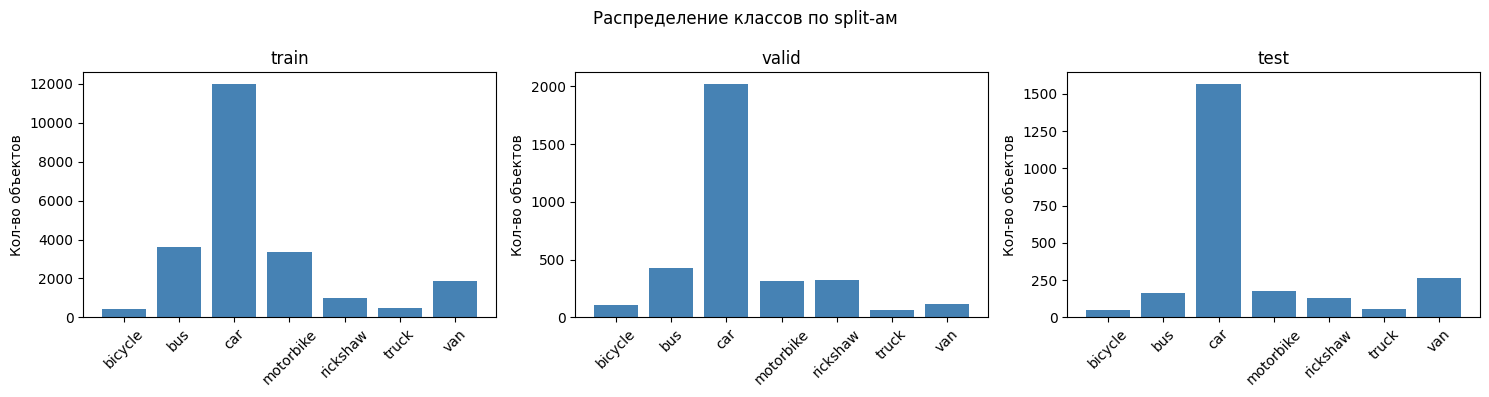

Saved: C:\Users\777\Desktop\8 сем\Практика\vehicle-counting\results\class_distribution.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, SPLITS):
    counts = reports[split]["class_counts"]
    ax.bar(counts.keys(), counts.values(), color="steelblue")
    ax.set_title(split)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Кол-во объектов")

plt.suptitle("Распределение классов по split-ам")
plt.tight_layout()

chart_path = RESULTS / "class_distribution.png"
plt.savefig(chart_path, dpi=120, bbox_inches="tight")
plt.show()
print("Saved:", chart_path)

## Размеры изображений

In [13]:
import cv2
import numpy as np
from collections import Counter as Ctr


def imread_unicode(path):
    """OpenCV imread не работает с кириллицей в пути на Windows."""
    img = cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Не удалось прочитать изображение: {path}")
    return img


size_counter = Ctr()
sample_count = 0
max_sample = 500

for split in SPLITS:
    img_dir = DATA / split / "images"
    for p in img_dir.iterdir():
        if p.suffix.lower() not in IMAGE_EXTS:
            continue
        img = imread_unicode(p)
        h, w = img.shape[:2]
        size_counter[(w, h)] += 1
        sample_count += 1
        if sample_count >= max_sample:
            break
    if sample_count >= max_sample:
        break

print(f"Проверено изображений: {sample_count}")
print("\nТоп-5 разрешений:")
for (w, h), cnt in size_counter.most_common(5):
    print(f"  {w}x{h}: {cnt} шт.")

Проверено изображений: 500

Топ-5 разрешений:
  640x640: 500 шт.


## Визуальная проверка разметки

Случайные 6 изображений из train с нарисованными bbox. Сохраните скриншот для приложения к отчёту.

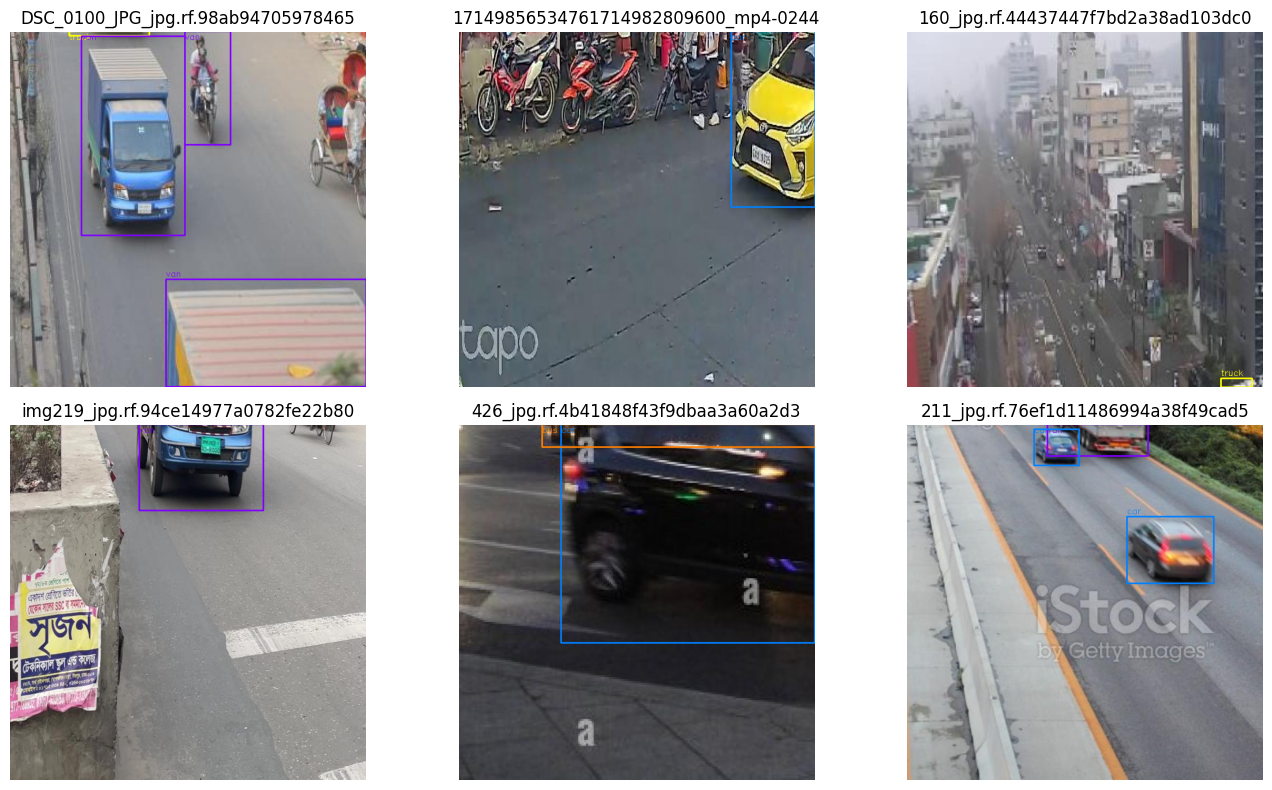

Saved: C:\Users\777\Desktop\8 сем\Практика\vehicle-counting\results\sample_labels.png


In [14]:
import random
import cv2
import numpy as np

COLORS = [(0, 255, 0), (255, 128, 0), (0, 128, 255), (255, 0, 128), (128, 255, 0), (255, 255, 0), (128, 0, 255)]


def imread_unicode(path):
    """OpenCV imread не работает с кириллицей в пути на Windows."""
    img = cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Не удалось прочитать изображение: {path}")
    return img


def find_image(img_dir, stem):
    for ext in IMAGE_EXTS:
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    matches = [p for p in img_dir.glob(f"{stem}.*") if p.suffix.lower() in IMAGE_EXTS]
    if not matches:
        raise FileNotFoundError(f"Изображение не найдено: {stem}")
    return matches[0]


def load_yolo_sample(split="train", n=6, seed=42):
    random.seed(seed)
    img_dir = DATA / split / "images"
    lbl_dir = DATA / split / "labels"
    stems = [p.stem for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
    picks = random.sample(stems, min(n, len(stems)))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, stem in zip(axes.ravel(), picks):
        img_path = find_image(img_dir, stem)
        img = cv2.cvtColor(imread_unicode(img_path), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lbl = lbl_dir / f"{stem}.txt"
        if lbl.exists():
            for line in lbl.read_text(encoding="utf-8").splitlines():
                if not line.strip():
                    continue
                cid, xc, yc, bw, bh = line.split()
                cid = int(cid)
                xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)
                color = COLORS[cid % len(COLORS)]
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(
                    img, CLASS_NAMES[cid], (x1, max(15, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1,
                )
        ax.imshow(img)
        ax.set_title(stem[:35])
        ax.axis("off")

    plt.tight_layout()
    out = RESULTS / "sample_labels.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


load_yolo_sample("train")